### Assignment 1 on Intensity Transformations and Neighborhood Filtering

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [12]:
img_orig = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)

def get_gamma(gamma):
    return np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

In [13]:
gamma_05 = get_gamma(0.5)
gamma_20 = get_gamma(2.0)

img_gamma_05 = cv.LUT(img_orig, gamma_05)
img_gamma_20 = cv.LUT(img_orig, gamma_20)

In [ ]:
def contrast_stretching(image, r1=0.2, r2=0.8):
    # 1. Normalize image to [0, 1] if it is in uint8 (0-255)
    r = image.astype(float) / 255.0
    
    # 2. Apply the piecewise formula
    s = (r - r1) / (r2 - r1)
    
    # Values < r1 will result in s < 0 -> clipped to 0
    # Values > r2 will result in s > 1 -> clipped to 1
    s = np.clip(s, 0, 1)
    
    # 3. Convert back to uint8 (0-255) for display/saving
    output = (s * 255).astype(np.uint8)
    
    return output

r1_val = 0.2
r2_val = 0.8

# Apply transformation
img_stretch = contrast_stretching(img_orig, r1=r1_val, r2=r2_val)

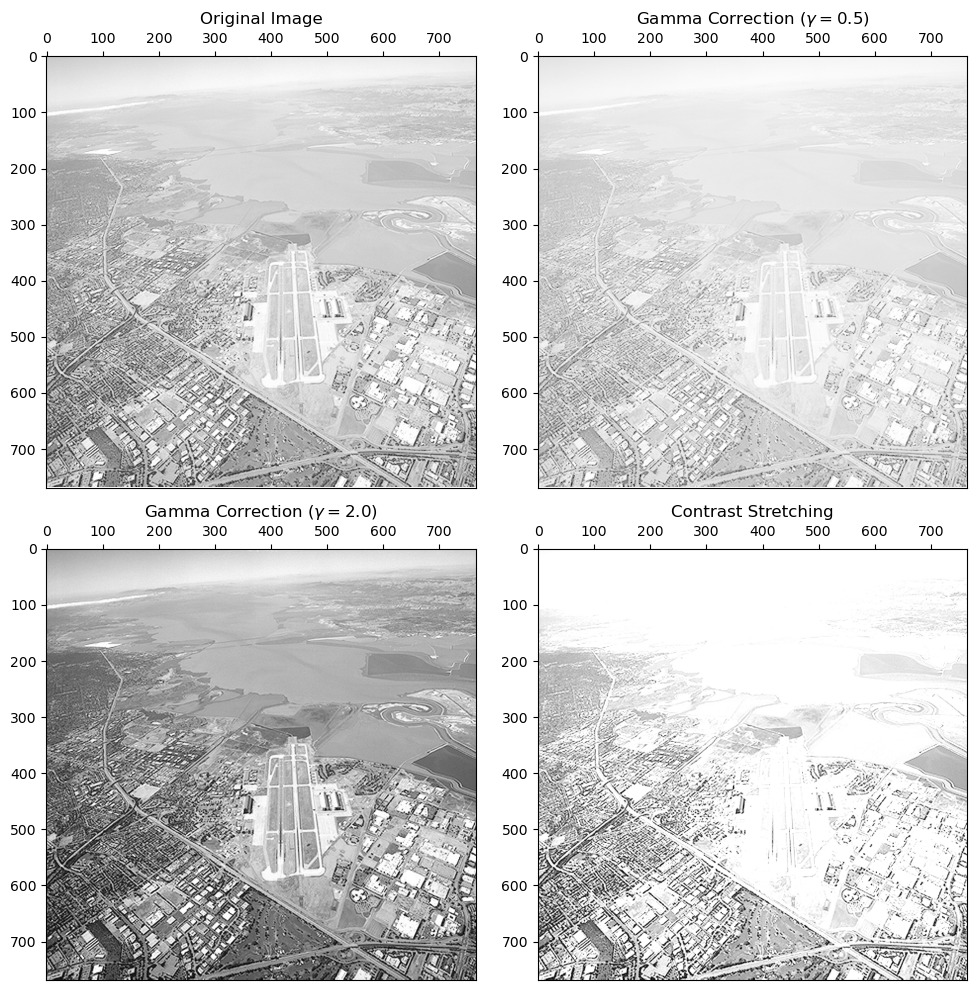

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Original
ax[0, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title('Original Image')
ax[0, 0].xaxis.set_ticks_position('top')

# Gamma 0.5
ax[0, 1].imshow(img_gamma_05, cmap='gray', vmin=0, vmax=255)
ax[0, 1].set_title(r'Gamma Correction ($\gamma=0.5$)')
ax[0, 1].xaxis.set_ticks_position('top')

# Gamma 2.0
ax[1, 0].imshow(img_gamma_20, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title(r'Gamma Correction ($\gamma=2.0$)')
ax[1, 0].xaxis.set_ticks_position('top')

# Contrast Stretching
ax[1, 1].imshow(img_stretch, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Contrast Stretching')
ax[1, 1].xaxis.set_ticks_position('top')

plt.tight_layout()
plt.show()